In [ ]:
print("Message Types in langchain")

In [ ]:
# ! uv pip install langchain-nebius

In [ ]:
import os
from dotenv import load_dotenv
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_core.messages import HumanMessage, SystemMessage

load_dotenv()

model = ChatNVIDIA(
    model="z-ai/glm-5.1",
    nvidia_api_key=os.getenv("NVIDIA_API_KEY"),
    temperature=1,
    top_p=1,
    max_tokens=16384,
)

messages = [
    SystemMessage("You are a helpful assistant."),
    HumanMessage("Explain transformers in 3 lines."),
]

# ── non-streaming ──────────────────────────────────────────────────────────
response = model.invoke(messages)
print(response.content)

# ── streaming ──────────────────────────────────────────────────────────────
for chunk in model.stream(messages):
    print(chunk.content, end="", flush=True)
print()  # newline after stream ends

C:\Users\Admin\AppData\Local\Temp\ipykernel_21288\1023822030.py:8: DeprecationWarning: The 'max_tokens' parameter is deprecated and will be removed in a future version. Please use 'max_completion_tokens' instead.
  model = ChatNVIDIA(
d:\Langchain-dev\.venv\Lib\site-packages\langchain_nvidia_ai_endpoints\_common.py:243: UserWarning: Found z-ai/glm-5.1 in available_models, but type is unknown and inference may fail.
  warnings.warn(


Transformers are neural networks that process entire sequences simultaneously using a mechanism called self-attention. 
This allows the model to weigh the relevance of all other parts of the input when processing any single element. 
They are the foundational architecture behind modern large language models and state-of-the-art AI.


In [5]:
# ── imports ────────────────────────────────────────────────────────────────
from langchain_nebius import ChatNebius
from langchain_nvidia import ChatNVIDIA
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from dotenv import load_dotenv
load_dotenv()

model = ChatNebius(model="nvidia/Nemotron-3-Nano-Omni", temperature=0.6)
# model = ChatNVIDIA(model="z-ai/glm4.7", temperature=0.6)


# ── format 1: string shortcut (single HumanMessage) ───────────────────────
response = model.invoke("What is machine learning?")

# ── format 2: message objects ─────────────────────────────────────────────
messages = [
    SystemMessage("You are a concise ML expert."),
    HumanMessage("What is machine learning?"),
]
response = model.invoke(messages)

# ── format 3: dict / OpenAI chat format ───────────────────────────────────
messages = [
    {"role": "system",    "content": "You are a concise ML expert."},
    {"role": "user",      "content": "What is machine learning?"},
    {"role": "assistant", "content": "ML is..."},   # inject prior AI turn
    {"role": "user",      "content": "Give an example."},
]

response = model.invoke(messages)

In [13]:
# ── imports ────────────────────────────────────────────────────────────────
from langchain_core.messages import HumanMessage

# ── basic text ────────────────────────────────────────────────────────────
msg = HumanMessage("What is the KV cache?")

# ── with optional metadata ────────────────────────────────────────────────
msg = HumanMessage(
    content="Hello!",
    name="akshay",      # identify the user (provider-dependent behavior)
    id="msg_001",       # for tracing / logging
)

# ── multimodal: text + image ──────────────────────────────────────────────
msg = HumanMessage(content=[
    {"type": "text",  "text": "What is in this image?"},
    {"type": "image", "url": "https://huggingface.co/blog/lmassaron/gemma-grpo"},
])

In [14]:
# ── imports ────────────────────────────────────────────────────────────────
from langchain_core.messages import HumanMessage

print("─" * 60)
print("HumanMessage: Basic Text")
print("─" * 60)
msg = HumanMessage("What is the KV cache?")
print("content :", msg.content)
print("type    :", msg.type)

print()
print("─" * 60)
print("HumanMessage: With Optional Metadata")
print("─" * 60)
msg = HumanMessage(
    content="Hello!",
    name="akshay",   # identify the user (provider-dependent behavior)
    id="msg_001",    # for tracing / logging
)
print("content :", msg.content)
print("name    :", msg.name)
print("id      :", msg.id)
print("type    :", msg.type)



────────────────────────────────────────────────────────────
HumanMessage: Basic Text
────────────────────────────────────────────────────────────
content : What is the KV cache?
type    : human

────────────────────────────────────────────────────────────
HumanMessage: With Optional Metadata
────────────────────────────────────────────────────────────
content : Hello!
name    : akshay
id      : msg_001
type    : human


In [15]:
# ── imports ────────────────────────────────────────────────────────────────
from langchain_core.messages import SystemMessage, HumanMessage

# ── simple ────────────────────────────────────────────────────────────────
system = SystemMessage("You are a helpful coding assistant.")

# ── detailed persona ──────────────────────────────────────────────────────
system = SystemMessage("""
You are a senior Python developer with expertise in LLM inference systems.
Always provide runnable code examples.
Be concise. Never explain what you are about to do — just do it.
""")

response = model.invoke([system, HumanMessage("How does vLLM handle KV cache?")])
print(response.content)


```python
from vllm import LLM, SamplingParams

# Load model (uses PagedKVCache internally)
llm = LLM(model="meta-llama/Llama-2-7b-hf", dtype="float16", tensor_parallel_size=1)

prompt = "Explain the difference between RNN and Transformer."
sampling_params = SamplingParams(temperature=0.7, max_tokens=64, stop=["\n"])

# First pass – builds KV cache
output1 = llm.generate(prompts=[prompt], sampling_params=sampling_params)
print(output1[0].outputs[0].text)

# Second pass – reuses the same cache (no re‑computation of past tokens)
new_prompt = "Give a short example."
output2 = llm.generate(prompts=[new_prompt], sampling_params=sampling_params, use_cache=True)
print(output2[0].outputs[0].text)
```


In [16]:
# ── imports ────────────────────────────────────────────────────────────────
from langchain_core.messages import SystemMessage, HumanMessage

print("─" * 60)
print("SystemMessage: Simple")
print("─" * 60)
system = SystemMessage("You are a helpful coding assistant.")
print("content :", system.content)
print("type    :", system.type)

print()
print("─" * 60)
print("SystemMessage: Detailed Persona")
print("─" * 60)
system = SystemMessage("""
You are a senior Python developer with expertise in LLM inference systems.
Always provide runnable code examples.
Be concise. Never explain what you are about to do — just do it.
""")
print("content :", system.content)
print("type    :", system.type)

print()
print("─" * 60)
print("Model Invocation — SystemMessage + HumanMessage")
print("─" * 60)
response = model.invoke([system, HumanMessage("How does vLLM handle KV cache?")])
print("response type :", response.type)
print("content :")
print(response.content)
print("─" * 60)

────────────────────────────────────────────────────────────
SystemMessage: Simple
────────────────────────────────────────────────────────────
content : You are a helpful coding assistant.
type    : system

────────────────────────────────────────────────────────────
SystemMessage: Detailed Persona
────────────────────────────────────────────────────────────
content : 
You are a senior Python developer with expertise in LLM inference systems.
Always provide runnable code examples.
Be concise. Never explain what you are about to do — just do it.

type    : system

────────────────────────────────────────────────────────────
Model Invocation — SystemMessage + HumanMessage
────────────────────────────────────────────────────────────
response type : ai
content :

vLLM stores the KV cache in a **paged, contiguous GPU memory pool** managed by its `PagedAttention` engine:

```python
from vllm import LLM, SamplingParams

# Load a model (uses the same KV‑cache mechanism under the hood)
llm = L

In [ ]:
# ── imports ────────────────────────────────────────────────────────────────
from langchain_core.messages import SystemMessage, HumanMessage

# ── simple ────────────────────────────────────────────────────────────────
system = SystemMessage("You are a helpful coding assistant.")

# ── detailed persona ──────────────────────────────────────────────────────
system = SystemMessage("""
You are a senior Python developer with expertise in LLM inference systems.
Always provide runnable code examples.
Be concise. Never explain what you are about to do — just do it.
""")

response = model.invoke([system, HumanMessage("How does vLLM handle KV cache?")])
print(response.content)

In [17]:
# ── imports ────────────────────────────────────────────────────────────────
from langchain_nebius import ChatNebius

from dotenv import load_dotenv
load_dotenv()

model = ChatNebius(model="nvidia/Nemotron-3-Nano-Omni", temperature=0.6)


response = model.invoke("Explain flash attention.")

# ── type ──────────────────────────────────────────────────────────────────
print(type(response))           # <class 'langchain_core.messages.ai.AIMessage'>

# ── text content ──────────────────────────────────────────────────────────
print(response.content)         # the actual answer text

# ── shortcut for text ─────────────────────────────────────────────────────
print(response.text)            # same as .content for text-only responses

# ── token usage ───────────────────────────────────────────────────────────
print(response.usage_metadata)
# {'input_tokens': 12, 'output_tokens': 187, 'total_tokens': 199}

# ── response metadata (model name, finish reason, etc.) ───────────────────
print(response.response_metadata)

# ── unique message ID ─────────────────────────────────────────────────────
print(response.id)

# ── tool calls (empty list if none) ──────────────────────────────────────
print(response.tool_calls)      # [] or [{"name": ..., "args": ..., "id": ...}]

<class 'langchain_core.messages.ai.AIMessage'>

## FlashAttention – a “fast‑track” version of the standard self‑attention mechanism  

### 1. Why FlashAttention was invented  

The classic **scaled‑dot‑product attention** used in Transformers computes  

\[
\text{Attention}(Q,K,V)=\text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V,
\]

where  

* \(Q, K, V\in\mathbb{R}^{n\times d_k}\) are the query, key and value matrices,  
* \(n\) is the sequence length, and  
* \(d_k\) is the head dimension.

The naïve implementation does three separate passes over the data:

1. **Matrix‑multiply** \(QK^\top\) → an \(n\times n\) attention score matrix.  
2. **Softmax** (row‑wise) on that matrix.  
3. **Matrix‑multiply** the softmax output with \(V\).

For long sequences (e.g., \(n = 16k\) or more) the \(n\times n\) matrix dominates both **memory** (O(n²) floats) and **compute** (O(n² d_k) operations).  
FlashAttention was introduced (Dao et al., 2022; “FlashAttention: Fast and Memory‑Efficient

In [18]:
# ── full usage_metadata structure ─────────────────────────────────────────
# guard against response or usage_metadata being None
usage = getattr(response, "usage_metadata", {}) or {}
# {
#   'input_tokens': 12,
#   'output_tokens': 187,
#   'total_tokens': 199,
#   'input_token_details':  {'cache_read': 0, 'audio': 0},
#   'output_token_details': {'reasoning': 120, 'audio': 0},  # if reasoning model
# }

input_toks    = usage.get("input_tokens",  0)
output_toks   = usage.get("output_tokens", 0)
reasoning_tok = usage.get("output_token_details", {}) .get("reasoning", 0)

In [20]:
input_toks, output_toks, reasoning_tok

(21, 3097, 0)

In [21]:
# ── inject a prior AI turn to simulate conversation history ────────────────
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

messages = [
    SystemMessage("You are a helpful assistant."),
    HumanMessage("Can you help me with Python?"),
    AIMessage("Of course! What do you need help with?"),   # injected manually
    HumanMessage("How do I sort a list?"),
]
response = model.invoke(messages)

In [23]:
# ── text content ──────────────────────────────────────────────────────────
print(response.content)         # the actual answer text


Sure! In Python there are two main ways to sort a list:

### 1. In‑place sorting with `list.sort()`
```python
my_list = [3, 1, 4, 1, 5, 9]
my_list.sort()          # modifies my_list directly
print(my_list)         # -> [1, 1, 3, 4, 5, 9]
```
- **Pros:** No extra memory (the list itself is reordered).  
- **Cons:** Returns `None`, so you can’t chain it.

### 2. Creating a new sorted list with `sorted()`
```python
my_list = [3, 1, 4, 1, 5, 9]
sorted_list = sorted(my_list)   # returns a new list, original unchanged
print(sorted_list)            # -> [1, 1, 3, 4, 5, 9]
print(my_list)                # -> [3, 1, 4, 1, 5, 9]
```
- **Pros:** Leaves the original list untouched; you can sort any iterable (e.g., a tuple, generator).  
- **Cons:** Uses extra memory for the new list.

### Optional arguments
Both functions accept the same optional arguments:

- `key=` – a function that extracts a comparison key from each element.  
  ```python
  words = ['apple', 'Banana', 'cherry']
  words.sort(ke

In [24]:
# ── token usage ───────────────────────────────────────────────────────────
print(response.usage_metadata)
# {'input_tokens': 12, 'output_tokens': 187, 'total_tokens': 199}

# ── response metadata (model name, finish reason, etc.) ───────────────────
print(response.response_metadata)

# ── unique message ID ─────────────────────────────────────────────────────
print(response.id)

{'input_tokens': 81, 'output_tokens': 523, 'total_tokens': 604, 'input_token_details': {}, 'output_token_details': {}}
{'token_usage': {'completion_tokens': 523, 'prompt_tokens': 81, 'total_tokens': 604, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'nvidia/Nemotron-3-Nano-Omni', 'system_fingerprint': None, 'id': 'chatcmpl-8faa64b6e2e8c0b0', 'finish_reason': 'stop', 'logprobs': None}
lc_run--019df0a1-31ac-7db3-a832-b1310061aded-0


In [25]:
# ── imports ────────────────────────────────────────────────────────────────
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage
from dotenv import load_dotenv
load_dotenv()

model = ChatNebius(model="nvidia/Nemotron-3-Nano-Omni", temperature=0.6)

# ── step 1: user asks, model decides to call a tool ───────────────────────
ai_msg = AIMessage(
    content=[],
    tool_calls=[{
        "name":  "get_stock_price",
        "args":  {"symbol": "NVDA"},
        "id":    "call_abc123",      # ← must reference this ID
    }]
)

# ── step 2: execute tool, wrap result ─────────────────────────────────────
tool_result = "NVDA: $875.20"
tool_msg = ToolMessage(
    content=tool_result,
    tool_call_id="call_abc123",      # ← must match ai_msg tool call id
    name="get_stock_price",
)

# ── step 3: model processes tool result ───────────────────────────────────
messages = [
    HumanMessage("What is NVIDIA's stock price?"),
    ai_msg,
    tool_msg,
]
response = model.invoke(messages)
print(response.content)


NVIDIA's stock price (NVDA) is currently **$875.20**.


In [26]:
# ── inspect ToolMessage fields ─────────────────────────────────────────────
print(tool_msg.content)        # "NVDA: $875.20"
print(tool_msg.tool_call_id)   # "call_abc123"
print(tool_msg.name)           # "get_stock_price"
print(tool_msg.type)           # "tool"

# ── full dict repr ─────────────────────────────────────────────────────────
print(tool_msg.model_dump())
# {
#   'content': 'NVDA: $875.20',
#   'tool_call_id': 'call_abc123',
#   'name': 'get_stock_price',
#   'type': 'tool',
#   'id': None,
#   'additional_kwargs': {},
#   ...
# }

# ── inspect AIMessage tool_calls ───────────────────────────────────────────
print(ai_msg.tool_calls)
# [{'name': 'get_stock_price', 'args': {'symbol': 'NVDA'}, 'id': 'call_abc123', 'type': 'tool_call'}]

print(ai_msg.tool_calls[0]["id"])    # "call_abc123"
print(ai_msg.tool_calls[0]["args"])  # {'symbol': 'NVDA'}

NVDA: $875.20
call_abc123
get_stock_price
tool
{'content': 'NVDA: $875.20', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'tool', 'name': 'get_stock_price', 'id': None, 'tool_call_id': 'call_abc123', 'artifact': None, 'status': 'success'}
[{'name': 'get_stock_price', 'args': {'symbol': 'NVDA'}, 'id': 'call_abc123', 'type': 'tool_call'}]
call_abc123
{'symbol': 'NVDA'}


In [27]:
import pandas as pd
from langchain_core.messages import ToolMessage

# ── tool returns both a summary and a raw dataframe ───────────────────────
df = pd.DataFrame({"price": [875.20, 876.10], "vol": [1_200_000, 980_000]})

tool_msg = ToolMessage(
    content="NVDA last 2 ticks: 875.20, 876.10",   # ← model reads this
    artifact=df,                                     # ← your code reads this
    tool_call_id="call_abc123",
    name="get_stock_price",
)

# ── access later in your pipeline ────────────────────────────────────────
print(tool_msg.content)     # "NVDA last 2 ticks: 875.20, 876.10"
print(tool_msg.artifact)    # the actual DataFrame

NVDA last 2 ticks: 875.20, 876.10
   price      vol
0  875.2  1200000
1  876.1   980000


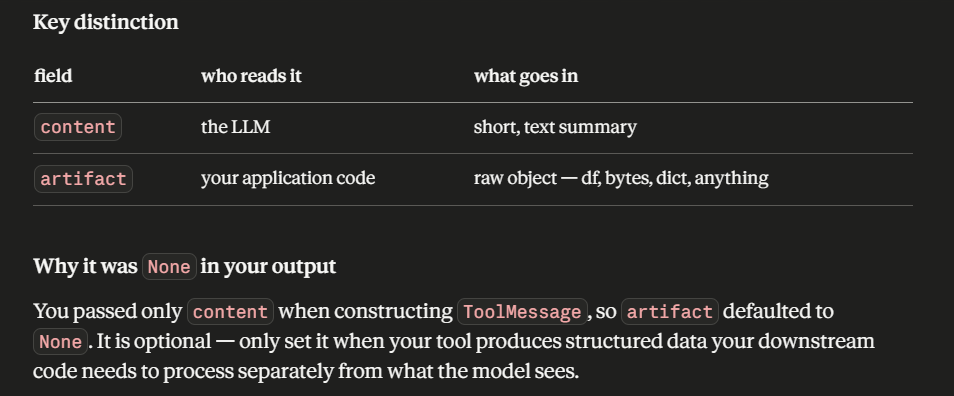

In [30]:
import base64, httpx
# base64 → converts binary bytes into ASCII-safe text
# httpx  → HTTP client (like requests, but supports async + redirects)


def url_to_base64(url: str) -> tuple[str, str]:
    # ── step 1: download the image ─────────────────────────────────────────
    resp = httpx.get(url, follow_redirects=True)
    # httpx.get()         → sends GET request to the URL
    # follow_redirects    → picsum.photos redirects to actual CDN image URL;
    #                       without this flag httpx stops at the 302 redirect
    #                       and resp.content would be empty/HTML, not image bytes
    #
    # dry run:
    #   URL hit   → https://picsum.photos/id/1015/800/600
    #   redirects → https://fastly.picsum.photos/id/1015/800/600.jpg?...
    #   resp.status_code  → 200
    #   resp.content      → b'\xff\xd8\xff\xe0...'  (raw JPEG bytes, ~80KB)

    # ── step 2: extract MIME type ──────────────────────────────────────────
    mime = resp.headers["content-type"].split(";")[0]
    # resp.headers["content-type"] → "image/jpeg; charset=utf-8"
    # .split(";")[0]               → "image/jpeg"   (drop everything after ;)
    # needed later to tell the model what kind of file it is receiving
    #
    # dry run:
    #   resp.headers["content-type"] → "image/jpeg"
    #   mime                         → "image/jpeg"

    # ── step 3: encode bytes to base64 string ──────────────────────────────
    b64 = base64.b64encode(resp.content).decode()
    # base64.b64encode(resp.content) → b'/9j/4AAQSkZJRgAB...'
    #                                   (bytes → base64 bytes)
    # .decode()                      → '/9j/4AAQSkZJRgAB...'
    #                                   (base64 bytes → plain Python string)
    # why base64? binary bytes cannot be embedded in JSON;
    #             base64 is ASCII-safe and JSON-serializable
    #
    # dry run:
    #   resp.content → b'\xff\xd8\xff\xe0...'   (binary, ~80KB)
    #   after b64encode + decode → '/9j/4AAQSkZJRgABAQ...'  (~110KB string)
    #                               (base64 inflates size by ~33%)

    return mime, b64
    # returns: ("image/jpeg", "/9j/4AAQSkZJRgAB...")


# ── call the function ──────────────────────────────────────────────────────
mime, b64 = url_to_base64("https://picsum.photos/id/1015/800/600")
# mime → "image/jpeg"
# b64  → "/9j/4AAQSkZJRgAB..."  (long base64 string)


# ── step 4: build the data URL ─────────────────────────────────────────────
data_url = f"data:{mime};base64,{b64}"
# data URL format → data:<mimetype>;base64,<base64string>
# this is a self-contained URL — no network request needed to resolve it,
# the entire image is embedded inside the string itself
#
# dry run:
#   data_url → "data:image/jpeg;base64,/9j/4AAQSkZJRgAB..."
#               ^    ^          ^      ^
#               |    mime type  |      actual image data
#               scheme          encoding method
#
# Nebius accepts this because the error said:
# "must be a valid http/https URL with allowed extension OR a valid data URL"
# this satisfies the second condition


# ── step 5: build HumanMessage with image ─────────────────────────────────
msg = HumanMessage(content=[
    {"type": "text",      "text": "Describe this image in one sentence."},
    # ↑ text block: the prompt the model reads

    {"type": "image_url", "image_url": {"url": data_url}},
    # ↑ image block: data_url carries the full image, no external fetch needed
    #   the model decodes the base64, reconstructs the JPEG, runs vision on it
])

# ── step 6: invoke model and print ────────────────────────────────────────
response = model.invoke([msg])
# model receives the full message list
# processes text prompt + image together (multimodal input)
# returns AIMessage

print(response.content)
# → "A serene river flows through a rocky mountain valley under a clear sky."


A group of people stands on the edge of a high, flat-topped cliff overlooking a deep blue fjord winding through a valley of rugged mountains under a blue sky with scattered clouds.


In [3]:
# ── imports ────────────────────────────────────────────────────────────────
import os
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openrouter import ChatOpenRouter

load_dotenv()

openrouter_key = os.getenv("OPENROUTER_API_KEY")
assert openrouter_key, "OPENROUTER_API_KEY is not set in .env"

model = ChatOpenRouter(
    model="nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free",
    api_key=openrouter_key, #type: ignore
    temperature=0.6,
    max_tokens=1024,
)


IMAGE_URL = "https://picsum.photos/id/1015/800/600.jpg"


# ── format 1: plain string (text only, no vision) ─────────────────────────
msg1 = HumanMessage("What is 2 + 2?")
r1 = model.invoke([msg1])
print("Format 1:", r1.content)

# ── format 2: provider-native list (OpenAI-style dict blocks) ─────────────
msg2 = HumanMessage(content=[
    {"type": "text", "text": "Describe this image in one sentence."},
    {"type": "image_url", "image_url": {"url": IMAGE_URL}},
])
r2 = model.invoke([msg2])
print("Format 2:", r2.content)

# ── format 3: LangChain standard content_blocks (cross-provider safe) ──────
msg3 = HumanMessage(content=[
    {"type": "text", "text": "What season does this image look like?"},
    {"type": "image_url", "image_url": {"url": IMAGE_URL}},
])
r3 = model.invoke([msg3])
print("Format 3:", r3.content)

# ── inspect what .content looks like on multimodal HumanMessage ───────────
print("\n--- msg2.content ---")
for block in msg2.content:
    print(block)


# ── reading content blocks from a response ────────────────────────────────
response = model.invoke("Explain speculative decoding step by step. Give in short one liner steps")
print("Response:", response.content)

Format 1: 4
Format 2: From a high vantage pointon a rocky cliff, a crowd of people looks out over a deep blue fjord that winds through steep, mountainous terrain under a blue sky.
Format 3: To determine the season, observe the vegetation, lighting, and human activity:  
- The landscape has green vegetation (not bare, as in winter) with some brownish patches, suggesting a warm season.  
- The bright blue sky, clear weather, and people dressed in light clothing (typical for warm temperatures) indicate favorable summer conditions.  
- This location (Preikestolen in Norway) is a popular summer tourist destination, with peak visitation during June–August when days are long and weather is mild.  

Thus, the image looks like **summer**.

--- msg2.content ---
{'type': 'text', 'text': 'Describe this image in one sentence.'}
{'type': 'image_url', 'image_url': {'url': 'https://picsum.photos/id/1015/800/600.jpg'}}
Response: **Speculative Decoding – one‑line steps**

1. **Sample a draft token** fro

In [4]:
# ── reading content blocks from a response ────────────────────────────────
response = model.invoke("Explain speculative decoding step by step. gvie in short one liner steps")

for block in response.content_blocks:
    if block["type"] == "text":
        print("Text:", block["text"])
    elif block["type"] == "reasoning":
        reasoning = block.get("reasoning", "") or block.get("text", "")
        print("Reasoning:", reasoning[:100], "...")
    elif block["type"] == "tool_call":
        print("Tool call:", block["name"], block["args"])

Reasoning: We need to explain speculative decoding step by step, with short one-liner steps. Provide concise bu ...
Text: **Speculative Decoding– one‑liner steps**

1. **Train a “student” model** to mimic the logits of a large “teacher” model on a massive dataset.  
2. **At inference**, feed the input to both teacher and student simultaneously.  
3. **Sample multiple tokens** (e.g., K candidates) from the *student* distribution in parallel.  
4. **Run the teacher** on the original input *once* to obtain its top‑K output sequence.  
5. **Compare** each student‑generated token (or whole sequence) with the teacher’s corresponding token(s).  
6. **If any student token matches** the teacher’s token at the same position → **accept** that token and continue to the next step.  
7. **If no match** after K attempts → **reject** the student output, fall back to the teacher (or abort).  
8. **Stream the accepted tokens** autoregressively, repeating steps 2‑6 until the sequence ends.  

*Result*: d

In [ ]:
# in cmd or powershell
! ping api.nebius.ai
! nslookup api.nebius.ai

In [2]:
import os
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openrouter import ChatOpenRouter

load_dotenv()

openrouter_key = os.getenv("OPENROUTER_API_KEY")
assert openrouter_key, "OPENROUTER_API_KEY is not set in .env"

model = ChatOpenRouter(
    model="nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free",
    api_key=openrouter_key, #type: ignore
    temperature=0.6,
    max_tokens=1024,
)

# ── format 1: plain string ─────────────────────────────────────────────────
r1 = model.invoke("What is 2 + 2?")
print("Format 1:", r1.content)

# ── format 2: system + human ───────────────────────────────────────────────
r2 = model.invoke([
    SystemMessage("You are a concise ML expert."),
    HumanMessage("Explain KV cache in 3 lines."),
])
print("Format 2:", r2.content)

# ── format 3: OpenAI-style dicts ───────────────────────────────────────────
r3 = model.invoke([
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user",   "content": "What is speculative decoding?"},
])
print("Format 3:", r3.content)

# ── streaming ──────────────────────────────────────────────────────────────
print("\nStreaming: ", end="")
for chunk in model.stream("Explain LoRA fine-tuning in short steps."):
    print(chunk.content, end="", flush=True)
print()

Format 1: 4
Format 2: KV cache storeskey‑value pairs from each transformer layer's attention computation.  
During generation it lets the model reuse past attention results instead of recomputing them.  
This speeds up inference, especially for long sequences, with O(1) per‑step cost.
Format 3: Speculative decoding isan inference‑speedup technique for large language models (LLMs). The idea is to **generate tokens faster by using a cheaper “draft” model to propose multiple candidate tokens in parallel, and then quickly verify those candidates with the original (more expensive) model**.

### How it works

1. **Draft model** – A smaller, faster model (often a distilled or quantized version of the target LLM) produces a *draft sequence* of tokens in one forward pass. Because it’s lightweight, it can generate many tokens per second.

2. **Parallel verification** – The draft tokens are sent to the **target model** (the full‑size LLM) in a batch. The target model evaluates all the draft token

In [5]:
import os
from dotenv import load_dotenv
from langchain_openrouter import ChatOpenRouter
from langchain_core.tools import tool
from pydantic import SecretStr

load_dotenv()

openrouter_key = os.getenv("OPENROUTER_API_KEY")
assert openrouter_key, "OPENROUTER_API_KEY is not set in .env"

model = ChatOpenRouter(
    model="nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free",
    api_key=SecretStr(openrouter_key),
    temperature=0.6,
    max_tokens=1024,
)

In [6]:
# ── sync streaming ────────────────────────────────────────────────────────
chunks = []
full_message = None

for chunk in model.stream("Explain PagedAttention in vLLM."):
    print(chunk.content, end="", flush=True)      # .content not .text
    chunks.append(chunk)
    full_message = chunk if full_message is None else full_message + chunk

print()
print(f"\nTotal chunks: {len(chunks)}")
print(f"Full response type: {type(full_message)}")
content = full_message.content if full_message is not None else ""
print(f"Content: {content}")

## PagedAttention in vLLM – A High‑Level Overview

**vLLM** (very Large‑Language‑Model inference engine) is a production‑ready serving library that aims at **high throughput, low latency, and massive context lengths** (hundreds of thousands of tokens).  
The key to achieving this is **PagedAttention**, a memory‑management technique borrowed from virtual‑memory operating systems and adapted to the attention mechanism of transformer models.

Below is a step‑by‑step explanation of what PagedAttention is, why it matters, how it works inside vLLM, and what its practical implications are.

---

## 1. The Problem that PagedAttention Solves

| Traditional “dense” attention | PagedAttention (vLLM) |
|------------------------------|-----------------------|
| **KV cache** is a **single contiguous tensor** of size *seq_len × (2·d_model)* (key + value per token). | The cache is **split into fixed‑size pages** (e.g., 16 KB each). |
| When the sequence grows, the whole cache must be **re‑allocated** 

In [7]:
# ── async streaming (works directly in Jupyter) ───────────────────────────
async def stream_response():
    async for chunk in model.astream("What is speculative decoding?"):
        print(chunk.content, end="", flush=True)

await stream_response()

**Speculative decoding** is an inference‑acceleration technique for large language models (LLMs) (and, more generally, for any model that produces a sequence of tokens). The idea is to **run two models in parallel**:

| Component | Role |
|-----------|------|
| **Draft model** (small, fast) | Generates a *candidate* next‑token sequence (often many tokens at once). |
| **Target model** (large, accurate) | Evaluates the draft’s proposals one‑by‑one and decides whether each token is correct. |

If the draft token(s) **match** the target model’s prediction, the token is **accepted** and the target model can skip the costly computation for that position. If they **don’t match**, the target model must still compute the correct token, but the rejection tells us the draft was wrong.

---

## How It Works (Step‑by‑Step)

1. **Prompt processing** – The input prompt is fed to both models (or to the draft model only, depending on the implementation).  
2. **Draft generation** – The draft model pro

In [8]:
# ── streaming with tool calls ─────────────────────────────────────────────
@tool
def get_stock_price(ticker: str) -> float:
    """Get the current stock price for a ticker symbol."""
    prices = {"NVDA": 1250.0, "AAPL": 189.0, "GOOGL": 175.0}
    return prices.get(ticker.upper(), 0.0)

model_with_tools = model.bind_tools([get_stock_price])

for chunk in model_with_tools.stream("What's the stock price of NVDA?"):
    # Check for tool calls in the chunk
    tool_calls = getattr(chunk, "tool_calls", None) or []
    if tool_calls:
        for tool_call in tool_calls:
            print(f"Tool: {tool_call.get('name')} | Args: {tool_call.get('args')}")
    # Alternative: check tool_call_chunks if available (during streaming)
    tool_call_chunks = getattr(chunk, "tool_call_chunks", None) or []
    if tool_call_chunks:
        for tool_chunk in tool_call_chunks:
            print(f"Tool: {tool_chunk.get('name')} | Args so far: {tool_chunk.get('args')}")

Tool: get_stock_price | Args: {}
Tool: get_stock_price | Args so far: 
Tool:  | Args: {}
Tool: None | Args so far: 
Tool:  | Args: {'ticker': 'NVDA'}
Tool: None | Args so far: {"ticker": "NVDA"}


In [9]:
# ── streaming with tool calls ─────────────────────────────────────────────
@tool
def get_stock_price(ticker: str) -> float:
    """Get the current stock price for a ticker symbol."""
    prices = {"NVDA": 1250.0, "AAPL": 189.0, "GOOGL": 175.0}
    return prices.get(ticker.upper(), 0.0)

model_with_tools = model.bind_tools([get_stock_price])

full_message = None

for chunk in model_with_tools.stream("What's the stock price of NVDA?"):
    # accumulate chunks
    full_message = chunk if full_message is None else full_message + chunk

    # text content tokens
    content = getattr(chunk, "content", "")
    if content:
        print(content, end="", flush=True)

    # tool_call_chunks — arrive during streaming (partial args)
    for tool_chunk in (getattr(chunk, "tool_call_chunks", None) or []):
        name = tool_chunk.get("name") or ""
        args = tool_chunk.get("args") or ""
        if name or args:
            print(f"\n[tool_call_chunk] name={name!r} | args_so_far={args!r}")

print("\n")

# ── final assembled message ───────────────────────────────────────────────
if full_message is not None:
    print(f"Response type : {type(full_message)}")
    print(f"Content       : {getattr(full_message, 'content', '')!r}")

    # tool_calls on assembled message — fully parsed, args is a dict here
    # Note: use .tool_calls (not .tool_call_chunks) on the final AIMessage
    tool_calls_list = getattr(full_message, 'tool_calls', None) or []
    if tool_calls_list:
        print(f"\nAssembled tool calls:")
        for tc in tool_calls_list:
            print(f"  name : {tc.get('name', 'N/A')}")
            print(f"  args : {tc.get('args', {})}")
            print(f"  id   : {tc.get('id', 'N/A')}")
else:
    print("No response received from the model.")


[tool_call_chunk] name='get_stock_price' | args_so_far=''

[tool_call_chunk] name='' | args_so_far='{"ticker": "NVDA"}'


Response type : <class 'langchain_core.messages.ai.AIMessageChunk'>
Content       : ''

Assembled tool calls:
  name : get_stock_price
  args : {'ticker': 'NVDA'}
  id   : call_b7fe06f70d094ae98fa9bd35


In [11]:
import os
from dotenv import load_dotenv

from langchain_openrouter import ChatOpenRouter
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, ToolMessage, AIMessage

load_dotenv()


@tool
def get_stock_price(ticker: str) -> float:
    """Get the current stock price for a ticker symbol."""
    prices = {"NVDA": 1250.0, "AAPL": 189.0, "GOOGL": 175.0}
    return prices.get(ticker.upper(), 0.0)



model_with_tools = model.bind_tools([get_stock_price])


print("=== Turn 1: streaming tool decision ===")

full_message = None

for chunk in model_with_tools.stream("What's the stock price of NVDA?"):
    full_message = chunk if full_message is None else full_message + chunk

    content = getattr(chunk, "content", "")
    if content:
        print(content, end="", flush=True)

    for tool_chunk in getattr(chunk, "tool_call_chunks", []) or []:
        name = tool_chunk.get("name") or ""
        args = tool_chunk.get("args") or ""
        if name or args:
            print(f"\n[tool_call_chunk] name={name!r} | args_so_far={args!r}")


print()
print(f"\nResponse type : {type(full_message)}")
print(f"Content       : {getattr(full_message, 'content', '')!r}")

tool_calls_list = getattr(full_message, "tool_calls", []) or []

if tool_calls_list:
    print("\nAssembled tool calls:")
    for tc in tool_calls_list:
        print(f"  name : {tc.get('name')}")
        print(f"  args : {tc.get('args')}")
        print(f"  id   : {tc.get('id')}")


print("\n=== Turn 2: execute tool + get final answer ===")

if tool_calls_list:
    tc = tool_calls_list[0]

    # execute the tool using its public API
    tool_args = tc.get("args") or {}
    tool_result = get_stock_price.invoke(tool_args)
    print(f"Tool result: {tool_result}")

    # robustly extract text from the assembled chunk/message
    if full_message is None:
        content_text = ""
    else:
        # prefer explicit .content, fall back to reasoning content in additional_kwargs
        content_text = getattr(full_message, "content", "") or getattr(
            getattr(full_message, "additional_kwargs", {}), "get", lambda k, d=None: d
        )("reasoning_content", "") or ""

    ai_msg = AIMessage(
        content=content_text,
        tool_calls=tool_calls_list,
    )

    final = model_with_tools.invoke(
        [
            HumanMessage(content="What's the stock price of NVDA?"),
            ai_msg,
            ToolMessage(
                content=str(tool_result),
                tool_call_id=tc["id"],
            ),
        ]
    )

    print(f"\nFinal response:\n{getattr(final, 'content', str(final))}")

else:
    print("Model returned text directly:")
    print(getattr(full_message, "content", ""))

=== Turn 1: streaming tool decision ===

[tool_call_chunk] name='get_stock_price' | args_so_far=''

[tool_call_chunk] name='' | args_so_far='{"ticker": "NVDA"}'


Response type : <class 'langchain_core.messages.ai.AIMessageChunk'>
Content       : ''

Assembled tool calls:
  name : get_stock_price
  args : {'ticker': 'NVDA'}
  id   : call_e18599e3ddae47258f171cf5

=== Turn 2: execute tool + get final answer ===
Tool result: 1250.0

Final response:
The current stock price for NVDA is $1250.0.


In [12]:
import os
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, HumanMessage, ToolMessage
from langchain_core.tools import tool
from langchain_openrouter import ChatOpenRouter
from pydantic import SecretStr
load_dotenv()

openrouter_key = os.getenv("OPENROUTER_API_KEY")
assert openrouter_key, "OPENROUTER_API_KEY is not set in .env"

model = ChatOpenRouter(
    model="nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free",
    api_key=SecretStr(openrouter_key),
    temperature=0.6,
    max_tokens=1024,
)

@tool
def get_gpu_specs(model_name: str) -> str:
    """Get technical specifications for an NVIDIA GPU model."""
    specs = {
        "H100": "80GB HBM3, 3.35TB/s bandwidth, 989 TFLOPS BF16",
        "A100": "80GB HBM2e, 2TB/s bandwidth, 312 TFLOPS BF16",
    }
    return specs.get(model_name, f"No data for {model_name}")

model_w_tool = model.bind_tools([get_gpu_specs])
messages: list[BaseMessage] = [HumanMessage("What are the H100 GPU specs?")]

# ── turn 1: model decides to call a tool ──────────────────────────────────
ai_response = model_w_tool.invoke(messages)
messages.append(ai_response)
print(f"Turn 1 tool_calls: {ai_response.tool_calls}")

# ── execute tool calls ─────────────────────────────────────────────────────
for tc in ai_response.tool_calls:
    result = get_gpu_specs.invoke(tc["args"])
    print(f"Tool result: {result}")
    messages.append(ToolMessage(
        content=str(result),
        tool_call_id=tc["id"],
        name=tc["name"],
    ))

# ── turn 2: model synthesizes tool result ─────────────────────────────────
final = model_w_tool.invoke(messages)
print(f"\nFinal response:\n{final.content}")

Turn 1 tool_calls: [{'name': 'get_gpu_specs', 'args': {'model_name': 'H100'}, 'id': 'call_1a958d7146ec4cddbe6b7228', 'type': 'tool_call'}]
Tool result: 80GB HBM3, 3.35TB/s bandwidth, 989 TFLOPS BF16

Final response:
The H100GPU specifications include:
- **Memory**: 80GB HBM3
- **Bandwidth**: 3.35TB/s
- **Performance**: 989 TFLOPS (BF16)
